# Checkpoint Analysis
Loads all `.pt` checkpoints, extracts training history and metrics, and produces a ranking with mean ± std across seeds.


In [1]:
import os
import re
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')


## Configuration


In [2]:
FLAG = 1

In [ ]:
if FLAG == 0:
    CHECKPOINTS_ROOT = Path("../checkpoints_CNN")
elif FLAG == 1:
    CHECKPOINTS_ROOT = Path("../checkpoints_ResNets")

DEVICE = torch.device("cpu")

if FLAG ==  0 :
    SEED_FOLDER_PATTERN = re.compile(r"checkpoints_(\d+)$")
elif FLAG == 1:
    SEED_FOLDER_PATTERN = re.compile(r"checkpoints_ResNets_(\d+)$")



## 1. Scan and Load Checkpoints


In [4]:
def load_checkpoint(pt_path: Path, device=DEVICE) -> dict | None:
    try:
        try:
            ckpt = torch.load(pt_path, map_location=device, weights_only=True)
        except Exception:
            ckpt = torch.load(pt_path, map_location=device, weights_only=False)

        # metrics are stored under ckpt["metrics"] dict
        metrics = ckpt.get("metrics", {})

        return {
            "history":      ckpt.get("history",      None),
            "accuracy":     metrics.get("accuracy",     None),
            "top5_acc":     metrics.get("top5_acc",     None),
            "f1_macro":     metrics.get("f1_macro",     None),
            "f1_weighted":  metrics.get("f1_weighted",  None),
        }

    except Exception as e:
        print(f"  [WARN] Could not load {pt_path.name}: {e}")
        return None


# Structure: records[run_name][seed] = ckpt_data
records: dict[str, dict[int, dict]] = defaultdict(dict)

for folder in sorted(CHECKPOINTS_ROOT.iterdir()):
    if not folder.is_dir():
        continue
    m = SEED_FOLDER_PATTERN.match(folder.name)
    if not m:
        continue
    seed = int(m.group(1))

    for pt_file in sorted(folder.glob("*.pt")):
        # strip trailing _seed{N} suffix to normalise run names across seed folders
        run_name = re.sub(r"_seed\d+$", "", pt_file.stem)
        ckpt_data = load_checkpoint(pt_file)
        if ckpt_data is not None and ckpt_data["history"] is not None:
            records[run_name][seed] = ckpt_data

print(f"Total unique runs found: {len(records)}")


Total unique runs found: 20


## 2. Extract Best-Epoch Metrics per Seed


In [5]:
def best_metrics(ckpt_data: dict) -> dict:
    history = ckpt_data["history"]
    val_accs  = np.asarray(history["val_acc"])
    best_epoch = int(np.argmax(val_accs))  # CNN trainer saves best-acc weights

    return {
        "best_val_acc":    float(val_accs[best_epoch]),
        "best_val_loss":   float(history["val_loss"][best_epoch]),
        "best_train_acc":  float(history["train_acc"][best_epoch]),
        "best_train_loss": float(history["train_loss"][best_epoch]),
        "best_epoch":      best_epoch + 1,
        "total_epochs":    len(val_accs),
        "accuracy":        ckpt_data["accuracy"],
        "top5_acc":        ckpt_data["top5_acc"],
        "f1_macro":        ckpt_data["f1_macro"],
        "f1_weighted":     ckpt_data["f1_weighted"],
    }


rows = []
for run_name, seed_dict in records.items():
    for seed, ckpt_data in seed_dict.items():
        m = best_metrics(ckpt_data)
        rows.append({"run": run_name, "seed": seed, **m})

df_raw = pd.DataFrame(rows)
print(df_raw.to_string(index=False))


                                                                       run  seed  best_val_acc  best_val_loss  best_train_acc  best_train_loss  best_epoch  total_epochs  accuracy  top5_acc  f1_macro  f1_weighted
                                                   custom_resnet18_ce_adam     0      0.877885       1.244772        0.958884         1.036094          40            40  0.875000  0.971154  0.873852     0.873050
                                                   custom_resnet18_ce_adam     1      0.898077       1.198567        0.943256         1.057817          38            40  0.892308  0.977885  0.892169     0.891766
                                                   custom_resnet18_ce_adam  1010      0.887500       1.201702        0.946862         1.053845          39            40  0.886538  0.975000  0.886128     0.885710
                                                   custom_resnet18_ce_adam  2026      0.886538       1.215109        0.955518         1.050157          

## 3. Aggregate: Mean and Std Across Seeds


In [6]:
agg_metrics = [
    "best_val_acc", "best_val_loss",
    "best_train_acc", "best_train_loss",
    "best_epoch", "total_epochs",
    "accuracy", "top5_acc",
    "f1_macro", "f1_weighted",
]

grouped  = df_raw.groupby("run")[agg_metrics]
df_mean  = grouped.mean().add_suffix("_mean")
df_std   = grouped.std(ddof=1).add_suffix("_std").fillna(0.0)
df_count = df_raw.groupby("run").size().rename("n_seeds")

df_agg = pd.concat([df_count, df_mean, df_std], axis=1).reset_index()
df_agg = df_agg.sort_values("best_val_acc_mean", ascending=False).reset_index(drop=True)
df_agg.index += 1
df_agg.index.name = "rank"

display_cols = [
    "run", "n_seeds",
    "best_val_acc_mean", "best_val_acc_std",
    "accuracy_mean", "accuracy_std",
    "top5_acc_mean", "top5_acc_std",
    "f1_macro_mean", "f1_macro_std",
    "f1_weighted_mean", "f1_weighted_std",
    "best_val_loss_mean", "best_val_loss_std",
    "best_train_acc_mean", "best_train_acc_std",
    "total_epochs_mean",
]

print("=== Ranking (sorted by val_acc mean, descending) ===")
print(df_agg[display_cols].to_string())


=== Ranking (sorted by val_acc mean, descending) ===
                                                                             run  n_seeds  best_val_acc_mean  best_val_acc_std  accuracy_mean  accuracy_std  top5_acc_mean  top5_acc_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  best_val_loss_mean  best_val_loss_std  best_train_acc_mean  best_train_acc_std  total_epochs_mean
rank                                                                                                                                                                                                                                                                                                                                                       
1                                                    pretrained_resnet50_ce_adam        5           0.952308          0.009460       0.949808      0.010002       0.989231      0.004681       0.949891      0.010455          0.949702         0.010347   

## 5. Bar Chart — Val Accuracy Ranking


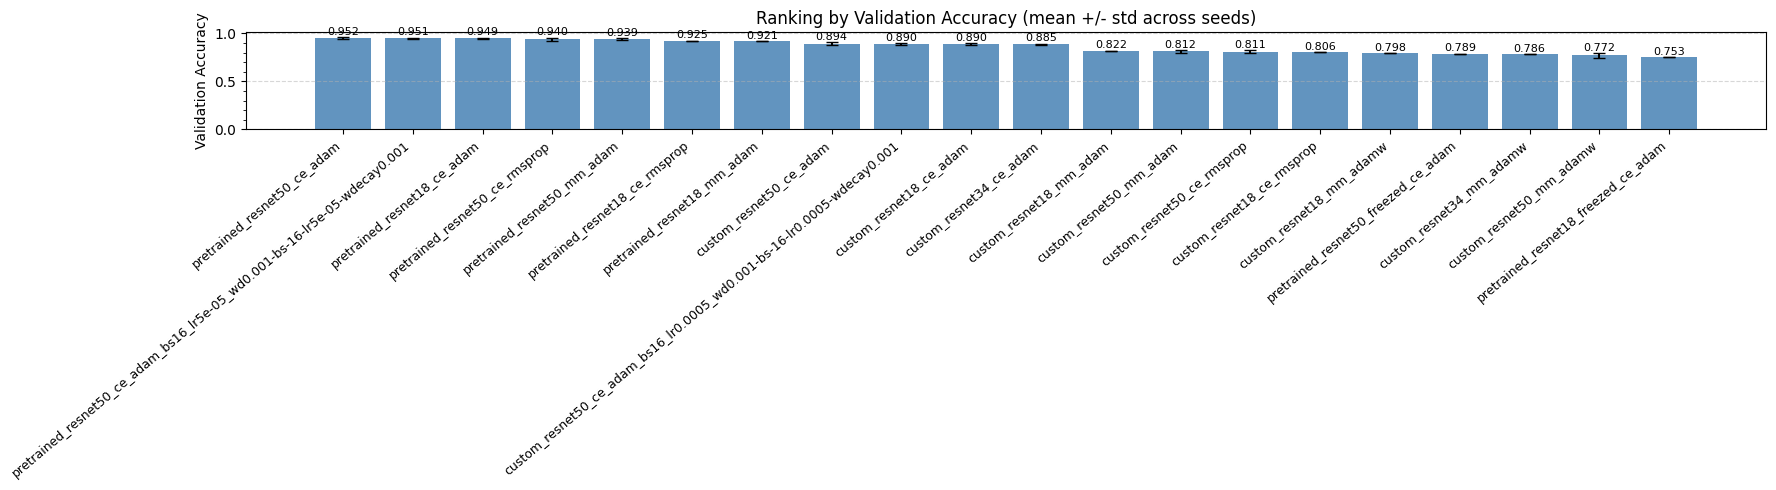

In [7]:
runs  = df_agg["run"].tolist()
means = df_agg["best_val_acc_mean"].to_numpy()
stds  = df_agg["best_val_acc_std"].to_numpy()
x     = np.arange(len(runs))

fig, ax = plt.subplots(figsize=(max(10, len(df_agg) * 0.9), 5))

bars = ax.bar(
    x, means, yerr=stds,
    capsize=4, color="steelblue", alpha=0.85,
    ecolor="black", linewidth=0.8,
)

for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.003,
        f"{mean:.3f}",
        ha="center", va="bottom", fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Validation Accuracy")
ax.set_title("Ranking by Validation Accuracy (mean +/- std across seeds)")
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.5)

upper = float((means + stds).max()) if len(means) > 0 else 1.0
ax.set_ylim(0, min(1.05, upper + 0.05))

plt.tight_layout()
plt.savefig(CHECKPOINTS_ROOT / "figures" / "val_acc_ranking.png", dpi=150)
plt.show()


## 6. Learning Curves per Run (all seeds overlaid)


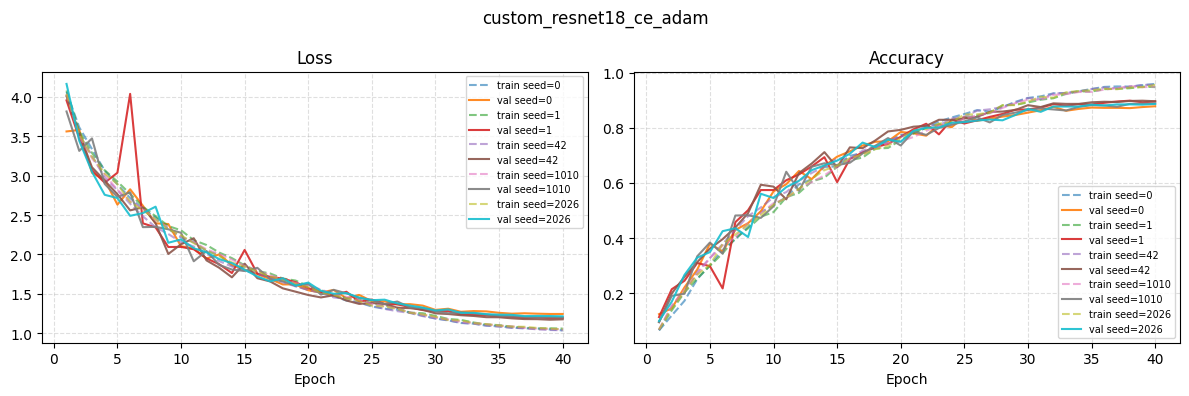

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet18_ce_adam_curves.png


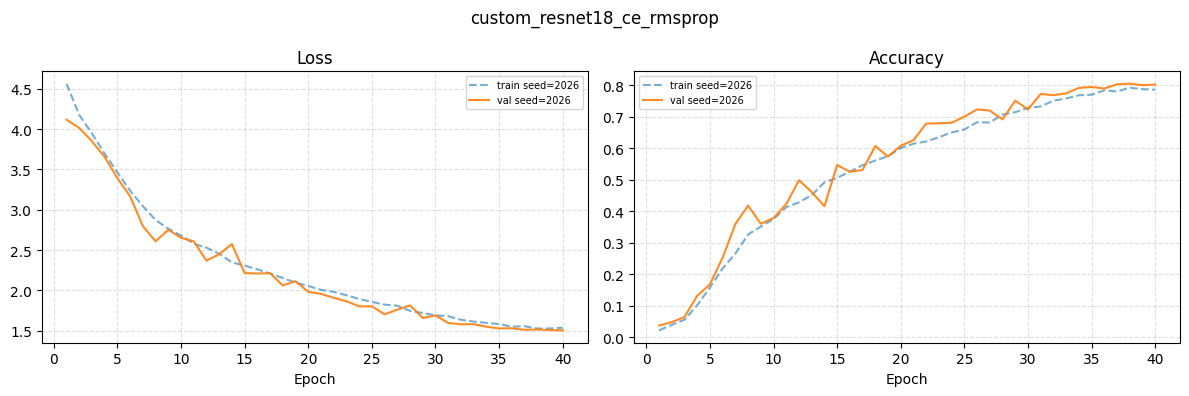

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet18_ce_rmsprop_curves.png


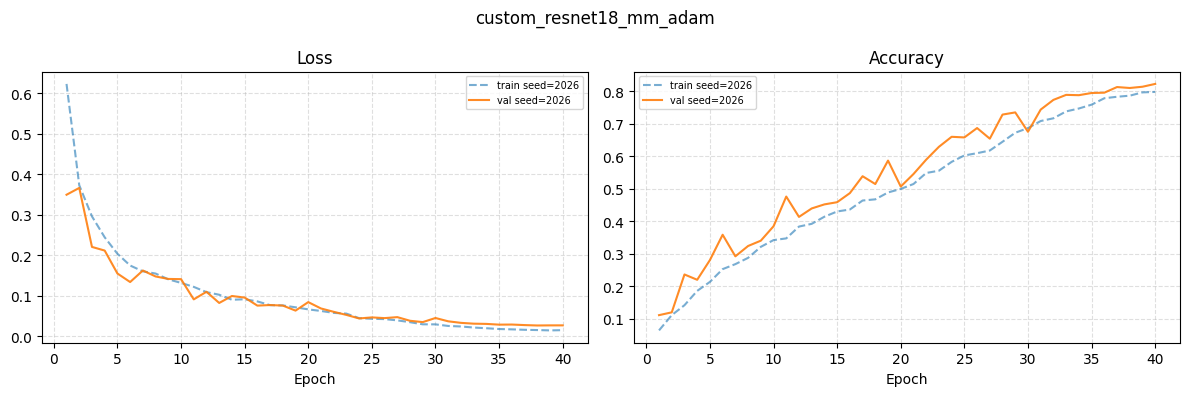

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet18_mm_adam_curves.png


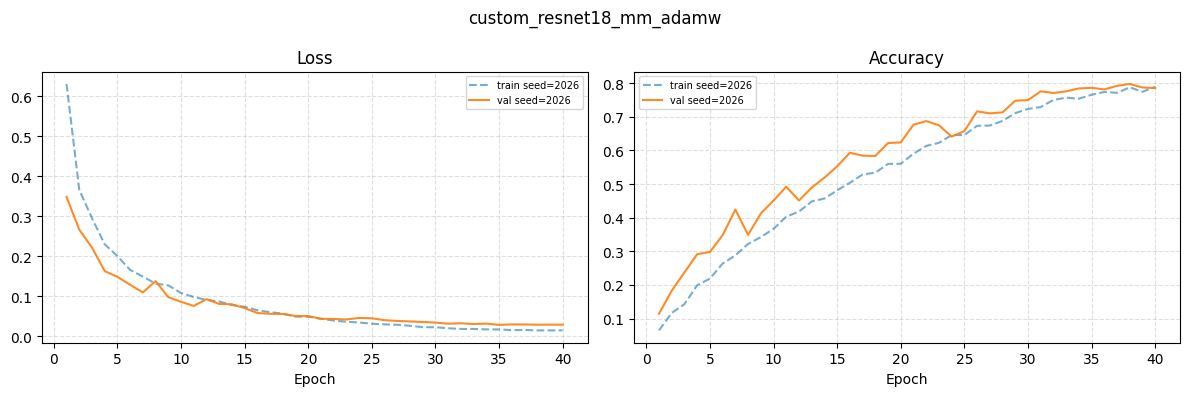

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet18_mm_adamw_curves.png


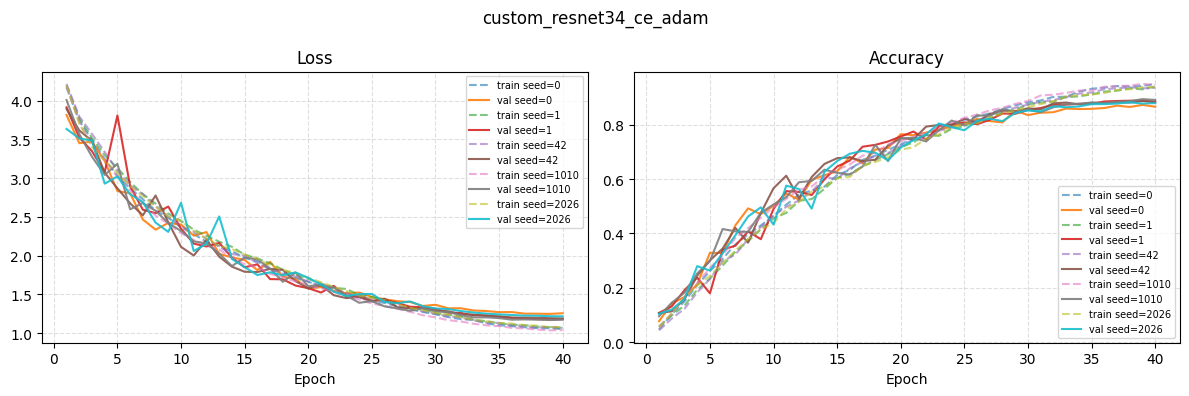

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet34_ce_adam_curves.png


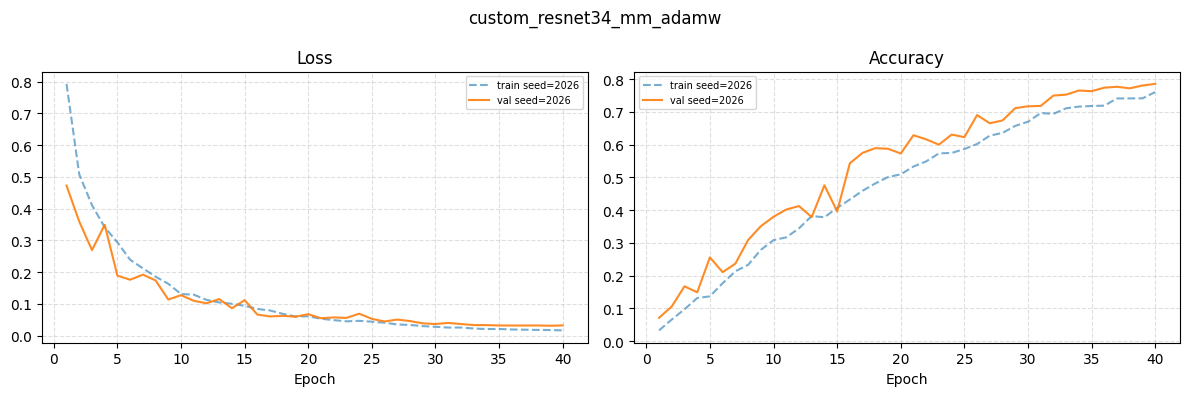

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet34_mm_adamw_curves.png


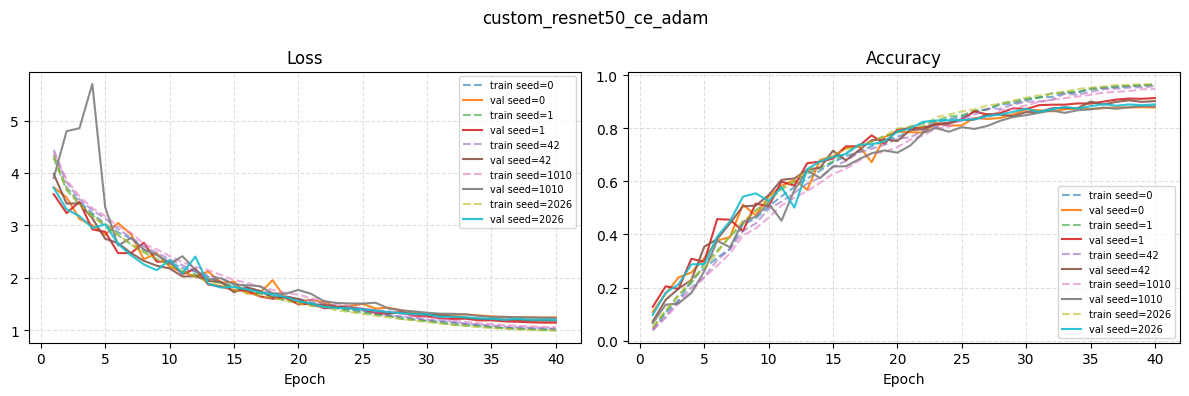

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet50_ce_adam_curves.png


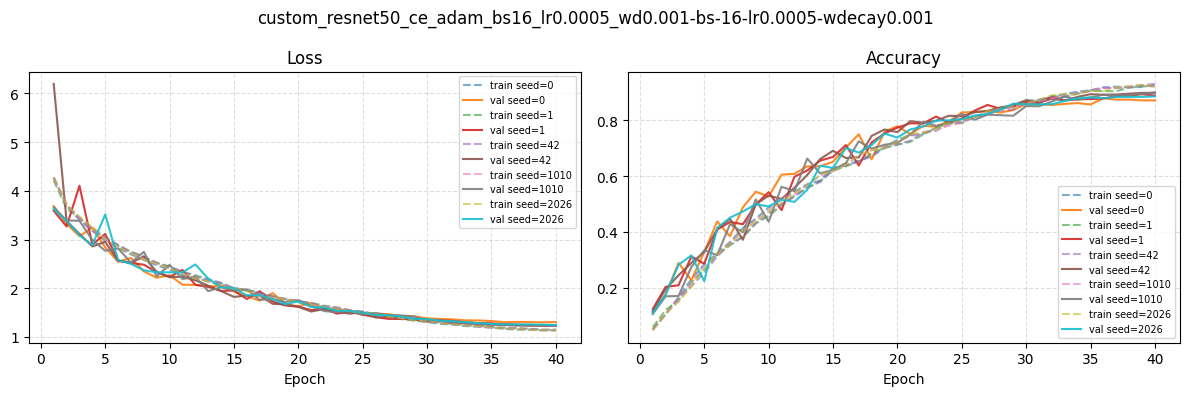

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet50_ce_adam_bs16_lr0.0005_wd0.001-bs-16-lr0.0005-wdecay0.001_curves.png


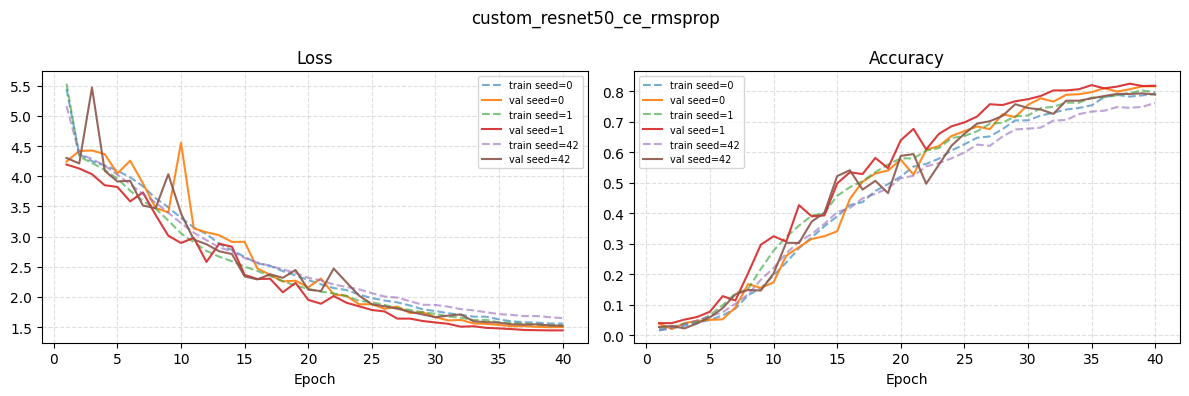

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet50_ce_rmsprop_curves.png


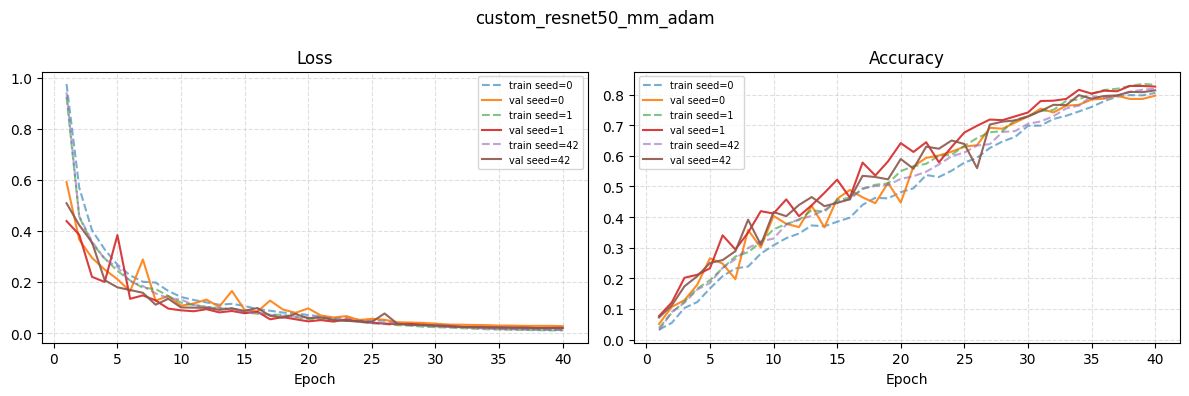

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet50_mm_adam_curves.png


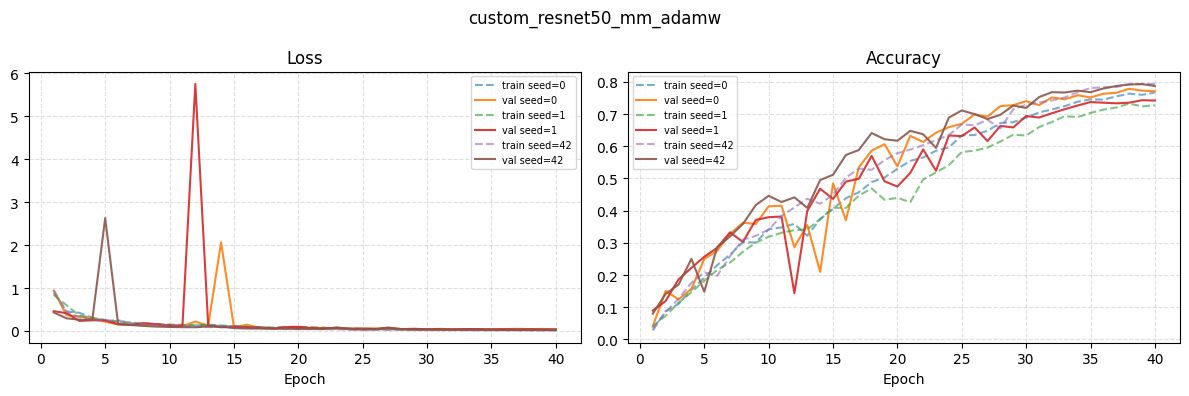

Saved: ../checkpoints_ResNets/figures/individual/custom_resnet50_mm_adamw_curves.png


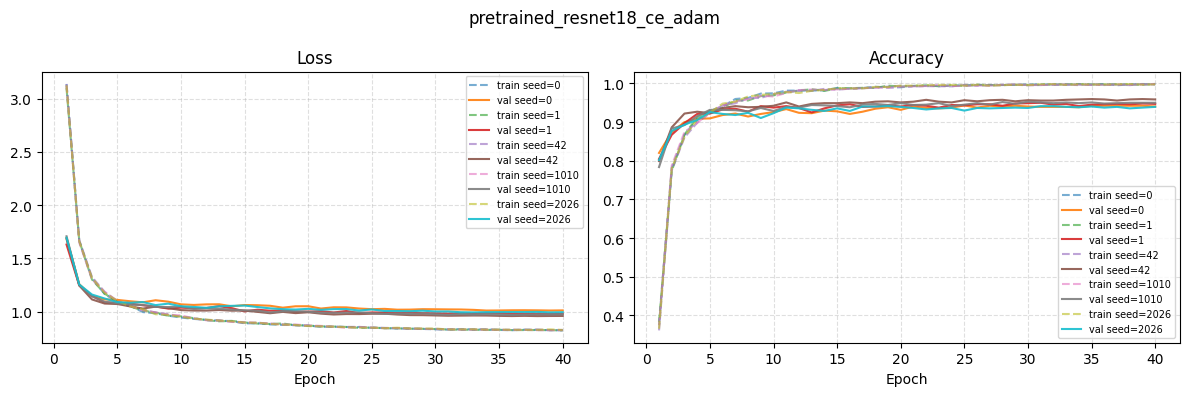

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet18_ce_adam_curves.png


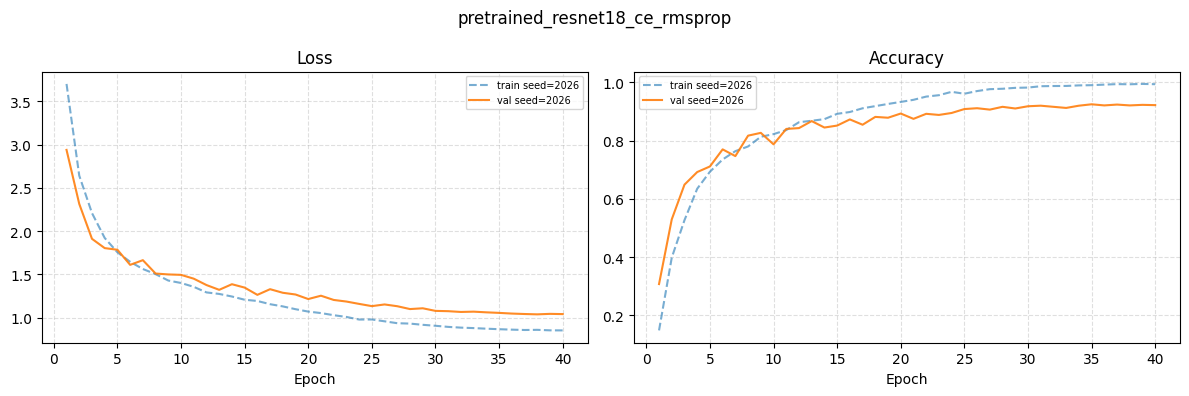

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet18_ce_rmsprop_curves.png


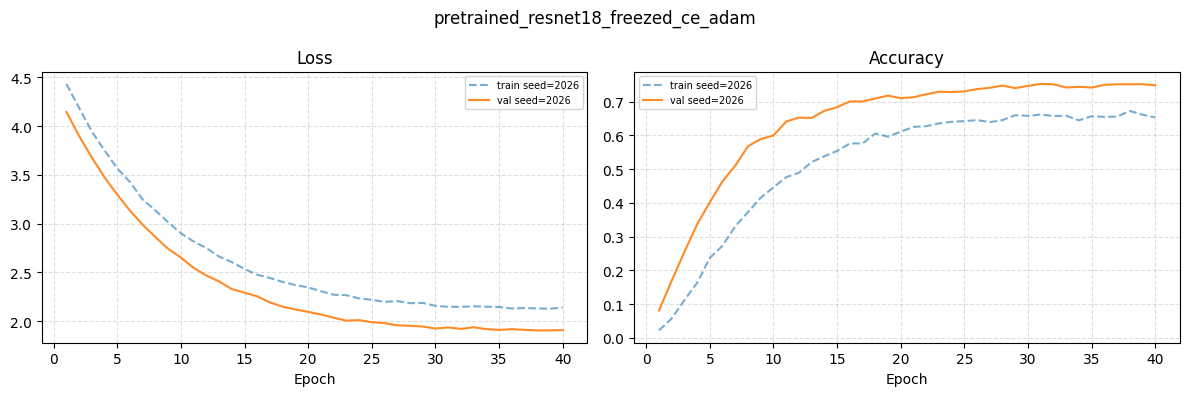

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet18_freezed_ce_adam_curves.png


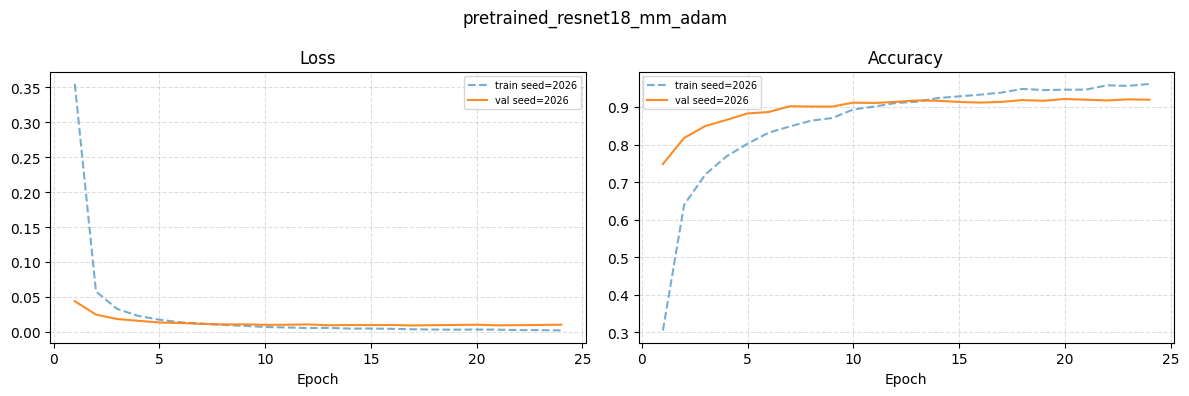

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet18_mm_adam_curves.png


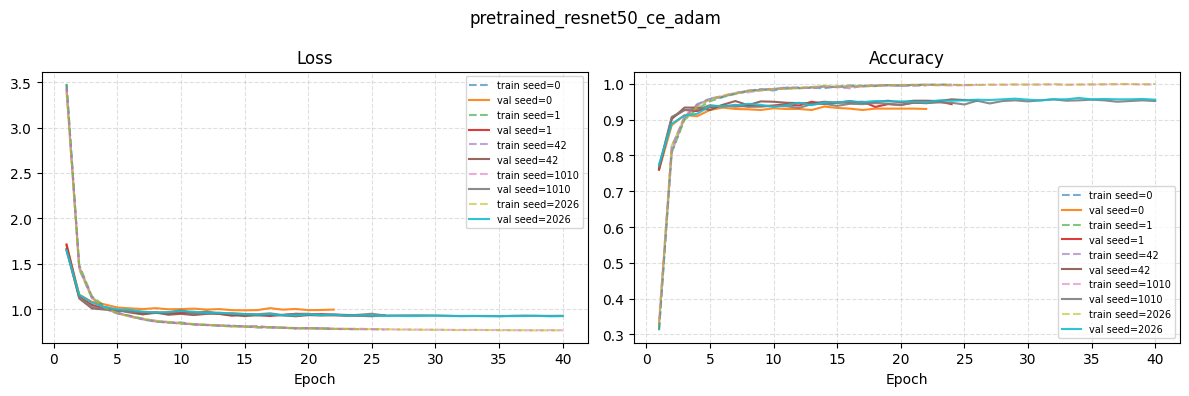

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet50_ce_adam_curves.png


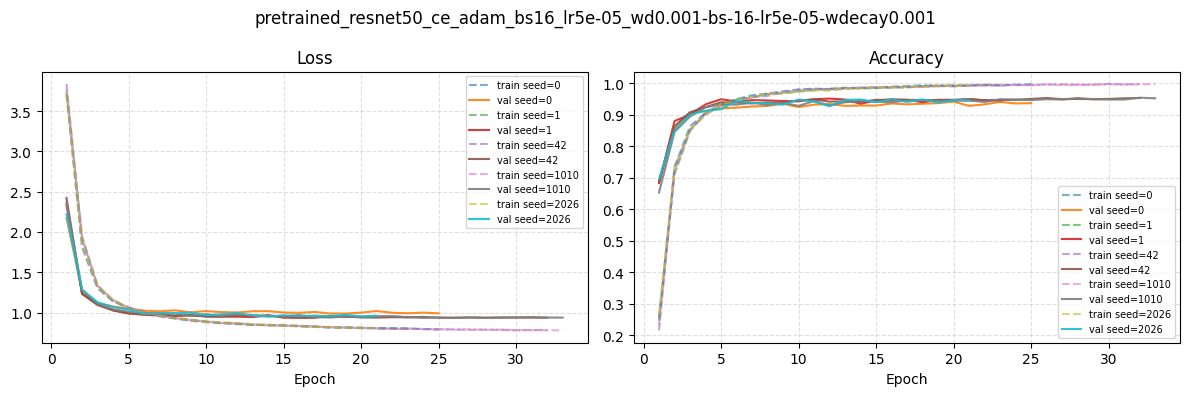

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet50_ce_adam_bs16_lr5e-05_wd0.001-bs-16-lr5e-05-wdecay0.001_curves.png


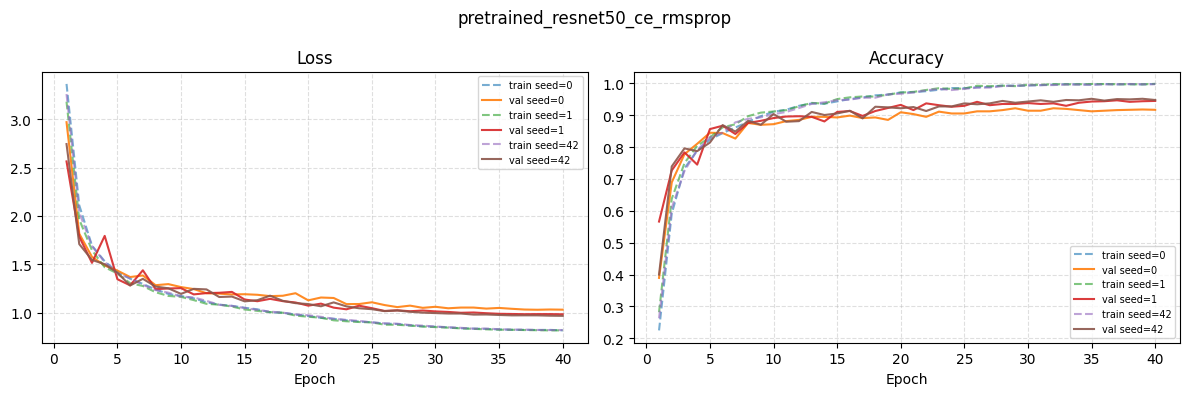

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet50_ce_rmsprop_curves.png


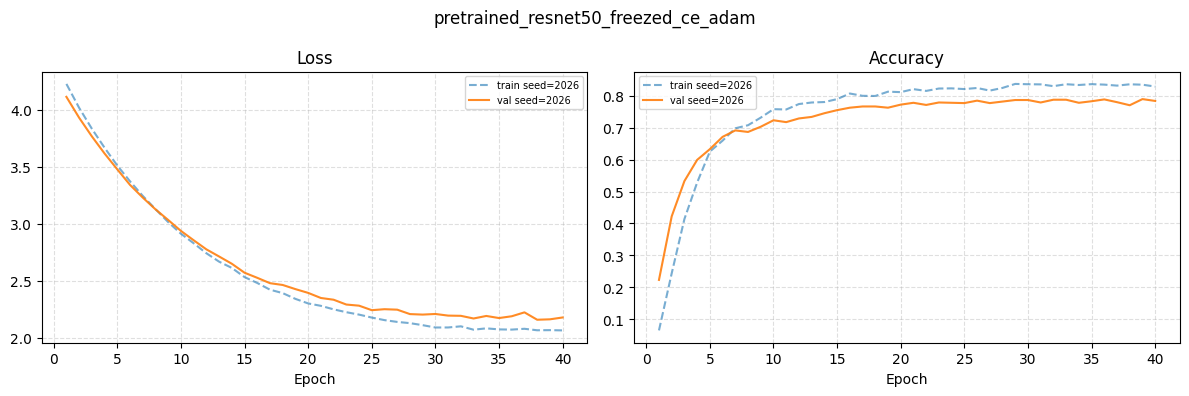

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet50_freezed_ce_adam_curves.png


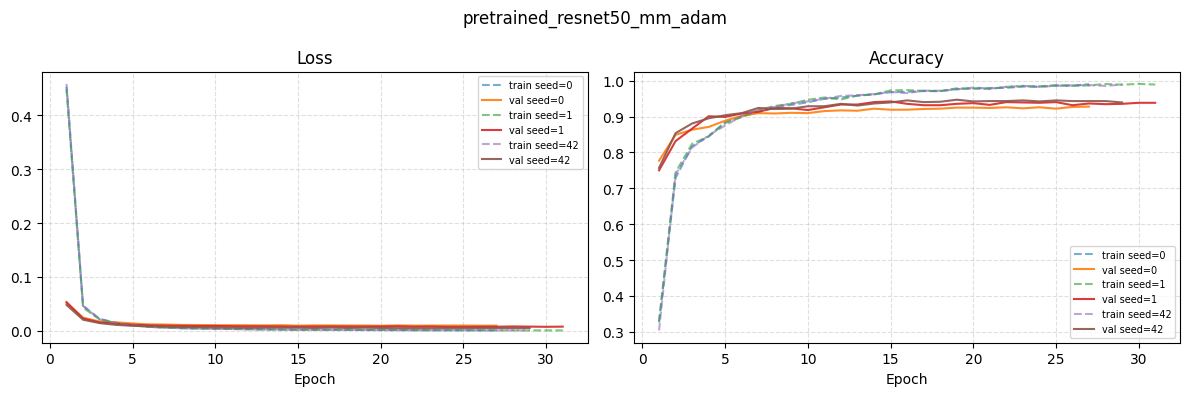

Saved: ../checkpoints_ResNets/figures/individual/pretrained_resnet50_mm_adam_curves.png


In [8]:
figures_dir = CHECKPOINTS_ROOT / "figures" / "individual"
figures_dir.mkdir(parents=True, exist_ok=True)

for run_name, seed_dict in sorted(records.items()):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(run_name, fontsize=12)

    for seed, ckpt_data in sorted(seed_dict.items()):
        history = ckpt_data["history"]
        epochs  = range(1, len(history["train_loss"]) + 1)
        label   = f"seed={seed}"

        axes[0].plot(epochs, history["train_loss"], linestyle="--", alpha=0.6, label=f"train {label}")
        axes[0].plot(epochs, history["val_loss"],   linestyle="-",  alpha=0.9, label=f"val {label}")
        axes[1].plot(epochs, history["train_acc"],  linestyle="--", alpha=0.6, label=f"train {label}")
        axes[1].plot(epochs, history["val_acc"],    linestyle="-",  alpha=0.9, label=f"val {label}")

    for ax, title in zip(axes, ["Loss", "Accuracy"]):
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=7)
        ax.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()
    out_path = figures_dir / f"{run_name}_curves.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {out_path}")
